In [1]:
import os
os.chdir("..")

In [2]:
from prsal_repl import PrsalReg
import bambi as bmb
import arviz as az
az.style.use("arviz-darkgrid")


prsal = PrsalReg()

In [3]:
df = prsal.make_pr_dataset()

/home/ouslan/Documents/Github/research-pr-salaries/src/prsal_repl/utils.py:230: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = weights.Queen.from_dataframe(base)
/home/ouslan/Documents/Github/research-pr-salaries/.venv/lib/python3.12/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
 There are 2 islands with ids: 72, 79.
  W.__init__(self, neighbors, ids=ids, **kw)


('WARNING: ', 72, ' is an island (no neighbors)')
('WARNING: ', 79, ' is an island (no neighbors)')


In [4]:
data = df[["zipcode", "year", "qtr", "k_index", "zip_employment", "w_employment", "w_k_index", "geometry"]]
data["time"] =  df["year"]*10 + df["qtr"]
data["zipcode"] = data["zipcode"].astype("category")
data["time"] = data["time"].astype("category")
data

,zipcode,year,qtr,k_index,zip_employment,w_employment,w_k_index,geometry,time
0,00601,2012,1,1.221839,7.919753,18.442734,1.049949,"POLYGON ((-66.83637 18.21014, -66.83602 18.210...",20121
1,00602,2012,1,1.134281,10.696833,14.569668,1.037781,"POLYGON ((-67.24044 18.38004, -67.23931 18.380...",20121
2,00603,2012,1,0.912660,18.224576,13.761089,1.028247,"POLYGON ((-67.17325 18.4768, -67.17253 18.4804...",20121
3,00606,2012,1,1.080357,30.012346,19.203483,1.074262,"POLYGON ((-67.05144 18.17416, -67.05134 18.174...",20121
4,00610,2012,1,1.010770,21.112033,15.239516,1.056068,"POLYGON ((-67.22692 18.29431, -67.22545 18.296...",20121
...,...,...,...,...,...,...,...,...,...
125,00979,2022,4,0.474838,18.269716,27.107181,0.505503,"POLYGON ((-66.04307 18.44408, -66.04306 18.444...",20224
126,00982,2022,4,0.461244,65.264706,44.785596,0.477783,"POLYGON ((-66.00795 18.41349, -66.0079 18.4135...",20224
127,00983,2022,4,0.482855,43.195076,47.926474,0.498602,"POLYGON ((-66.01707 18.41864, -66.01573 18.420...",20224
128,00985,2022,4,0.505102,91.270115,30.286339,0.497271,"POLYGON ((-65.97403 18.38888, -65.97388 18.389...",20224


In [5]:
model = bmb.Model(
    "zip_employment ~ k_index + w_employment + w_k_index + C(zipcode) + C(time)",
    data=data,
    family="gaussian"
)
idata = model.fit(
    draws=1000,
    tune=1000,
    target_accept=0.9
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, k_index, w_employment, w_k_index, C(zipcode), C(time)]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 63 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


/home/ouslan/Documents/Github/research-pr-salaries/.venv/lib/python3.12/site-packages/arviz/plots/traceplot.py:223: UserWarning: rcParams['plot.max_subplots'] (20) is smaller than the number of variables to plot (177), generating only 20 plots
  warnings.warn(


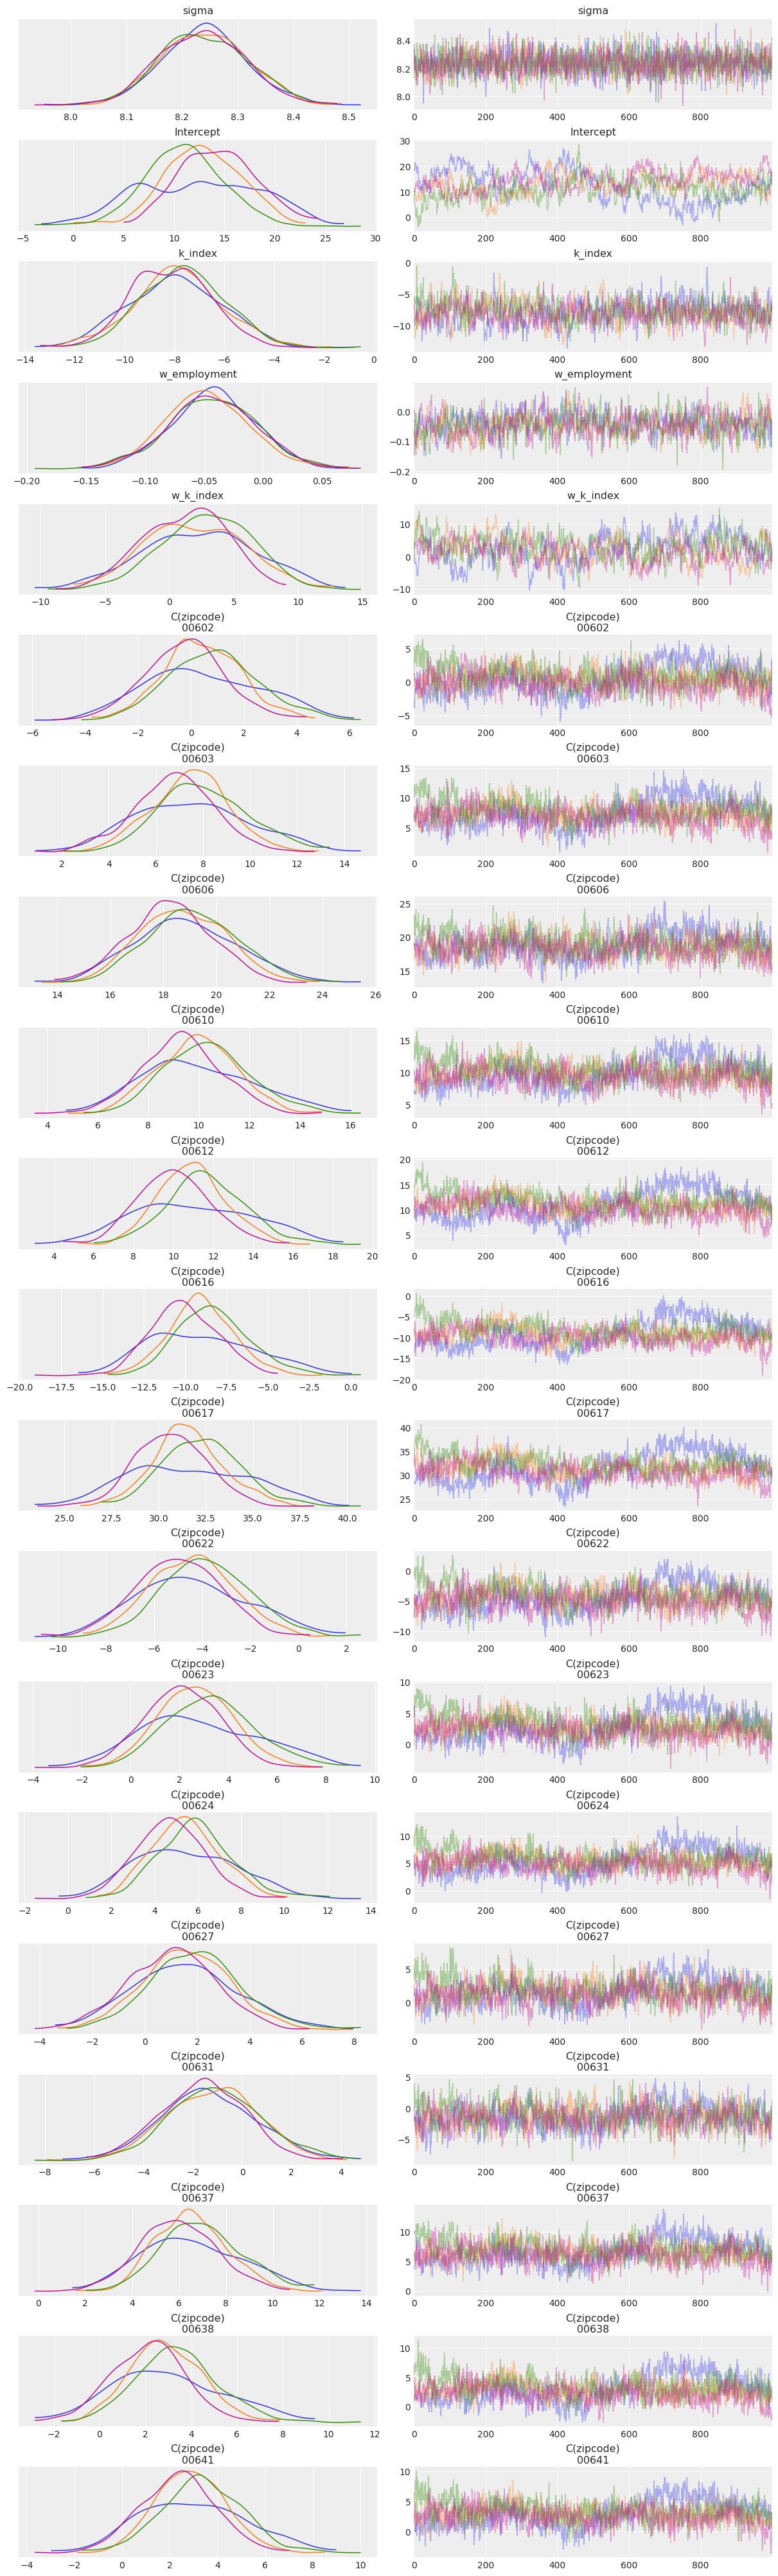

In [6]:
az.plot_trace(idata, compact=False);

In [7]:
az.summary(idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,8.239,0.078,8.102,8.392,0.002,0.001,2264.0,2770.0,1.00
Intercept,12.618,4.773,4.415,22.419,1.350,0.413,12.0,60.0,1.26
k_index,-7.900,1.761,-11.180,-4.631,0.137,0.038,168.0,1108.0,1.03
w_employment,-0.044,0.037,-0.122,0.020,0.002,0.001,509.0,1139.0,1.01
w_k_index,2.102,3.883,-5.314,9.266,0.727,0.132,29.0,157.0,1.10
...,...,...,...,...,...,...,...,...,...
C(time)[20214],5.789,1.381,3.179,8.287,0.261,0.052,28.0,367.0,1.10
C(time)[20221],6.161,1.219,3.722,8.375,0.203,0.041,36.0,346.0,1.08
C(time)[20222],3.726,1.249,1.494,6.115,0.212,0.043,35.0,338.0,1.08
C(time)[20223],3.888,1.272,1.529,6.206,0.222,0.046,33.0,353.0,1.08
